In [1]:
# !pip install gym==0.21.0
# !pip install gym-retro

In [1]:
import retro
from gymnasium import Env
from gymnasium.spaces import MultiBinary, Box
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

In [27]:
# Creating custom enviroments
class StreetFighter(Env):
    def __init__(self):
        super.__init__
        self.observation_space = Box(low=0, high=255, shape=(200, 256, 3), dtype=np.uint8)
        self.action_space = MultiBinary(12)
        self.game = retro.make(game="StreetFighterIISpecialChampionEdition-Genesis", use_restricted_actions = retro.Actions.FILTERED)
        
    def step(self, action):
        obs, reward, done, _, info = self.game.step(action)
        obs = self.pre_process(obs)

        frame_delta = obs - self.previous_frame 
        self.previous_frame = obs
        
        reward = info["score"] - self.score
        self.score = info["score"]

        return frame_delta, reward, done, info
        
    def render(self):
        self.game.render()
        
    def reset(self):
        obs, _ = self.game.reset()
        obs  = self.pre_process(obs)
        self.previous_frame = obs
        self.score = 0
        return obs
        
    def pre_process(self, observation):
        gray = cv2.cvtColor(observation, cv2.COLOR_BGR2GRAY)
        resize = cv2.resize(gray, (84, 84), interpolation=cv2.INTER_CUBIC)
        channels = np.reshape(resize, (84, 84, 1))

        return channels
        
    def close(self):
        self.game.close()
    

In [20]:
env = StreetFighter()
obs = env.reset()

In [40]:
env = StreetFighter()
obs = env.reset()
done = False
n_episodes = 1
for game in range(n_episodes):
    while not done:
        env.render()
        time.sleep(0.01)
        obs, reward, done, info = env.step(env.action_space.sample())
        if reward > 0:
            print(reward)
        

100
1000
500
500
500
1000
500
1500


KeyboardInterrupt: 

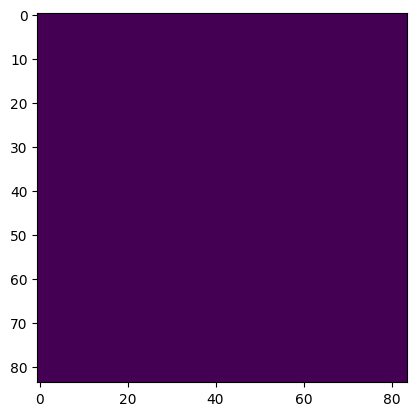

In [38]:
# The obs is the delta (difference) between two consecutive frames, so if it is a black (puprple) screen, it means that the image didn't change. 
plt.imshow(obs)

In [41]:
env.close()

In [42]:
info

{'continuetimer': 0,
 'enemy_health': -1,
 'enemy_matches_won': 0,
 'health': 1,
 'matches_won': 1,
 'score': 5600}

In [1]:
import optuna
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack
from env import StreetFighter
import os

In [2]:
LOG_DIR = "./logs/"
OPT_DIR = "./opt/"

In [3]:
def optimize_ppo(trial):
    return {
        "n_steps" : trial.suggest_int("n_steps", 2048, 8192),
        "gamma" : trial.suggest_float("gamma ", 0.8, 0.9999, log=True),
        "learning_rate" : trial.suggest_float("learning_rate", 1e-5, 1e-4, log=True),
        "clip_range" : trial.suggest_uniform("clip_range", 0.1, 0.4),
        "gae_lambda" : trial.suggest_uniform("gae_lambda", 0.8, 0.99),
    }

In [4]:
def optimize_agent(trial):
    model_params = optimize_ppo(trial)
    env = StreetFighter()
    env = Monitor(env, LOG_DIR)
    env = DummyVecEnv([lambda: env])
    env = VecFrameStack(env, 4, channels_order="last")

    model = PPO("CnnPolicy", env, tensorboard_log=LOG_DIR, verbose=0, **model_params)
    model.learn(total_timesteps=30000)

    mean_reward, _ = evaluate_policy(model, env, n_eval_episodes=5)
    env.close()

    SAVE_PATH = os.path.join(OPT_DIR, "trial_{}_best_model".format(trial.number))
    model.save(SAVE_PATH)
    return mean_reward

In [5]:
study = optuna.create_study(direction="maximize") # Reward positive
study.optimize(optimize_agent, n_trials=10, n_jobs=1)

[I 2026-02-17 17:47:20,973] A new study created in memory with name: no-name-73be0312-8f1f-4a69-98b1-41407c614210
/tmp/ipykernel_123050/3878954549.py:6: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  "clip_range" : trial.suggest_uniform("clip_range", 0.1, 0.4),
/tmp/ipykernel_123050/3878954549.py:7: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  "gae_lambda" : trial.suggest_uniform("gae_lambda", 0.8, 0.99),
/home/ismael/.pyenv/versions/.stable_retro/lib/python3.12/site-packages/stable_baselines3/ppo/ppo.py:155: UserWarning: You have specified a mini-batch size of 64, but because the `RolloutBuffer` is of size `n_steps * n_envs = 6724`, after every 105 untruncated mini-batches, there will be a truncated mini

In [6]:
study.best_trial # Trial 9

FrozenTrial(number=9, state=<TrialState.COMPLETE: 1>, values=[3300.0], datetime_start=datetime.datetime(2026, 2, 17, 18, 58, 44, 422738), datetime_complete=datetime.datetime(2026, 2, 17, 19, 5, 47, 898950), params={'n_steps': 3521, 'gamma ': 0.9271492745360717, 'learning_rate': 1.0794359837673834e-05, 'clip_range': 0.24549056115952492, 'gae_lambda': 0.8653819861530365}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_steps': IntDistribution(high=8192, log=False, low=2048, step=1), 'gamma ': FloatDistribution(high=0.9999, log=True, low=0.8, step=None), 'learning_rate': FloatDistribution(high=0.0001, log=True, low=1e-05, step=None), 'clip_range': FloatDistribution(high=0.4, log=False, low=0.1, step=None), 'gae_lambda': FloatDistribution(high=0.99, log=False, low=0.8, step=None)}, trial_id=9, value=None)